In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import hoi
import xarray as xr

import sys
import pathlib
sys.path.append(str(pathlib.Path.cwd().parent.parent))
import ISRUtilities as isru
froot = pathlib.Path().cwd().parent.parent.parent / 'Results/Figures/ISAHpcPfc'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

/home/pietro/uvEnvs/hoi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import jax
def print_gpu_memory():
    for device in jax.devices("gpu"):
        stats = device.memory_stats()
        gib = 1024**3

        print(
            f"{device}: "
            f"in use={stats['bytes_in_use']/gib:.2f} GiB, "
            f"peak={stats['peak_bytes_in_use']/gib:.2f} GiB, "
            f"pool={stats['pool_bytes']/gib:.2f} GiB / "
            f"{stats['bytes_limit']/gib:.2f} GiB"
        )

In [3]:
def _regionTE(session,regs=None,when='sleep.*#0',bin=0.005,delay=1,shuffle=0,verbose=False):
    # note: no overlapping bins for time independence

    delay = np.array(delay,ndmin=1)

    R = fma.regions.regions(session,phases=when,events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    isa = R.eventIntervals('slownr')

    fr = R.firingRate(regs=regs,window=bin) # (time, region)
    _, is_isa = fma.general.restrict(fr,isa,s_ind=True)
    fr = (fr[:,1:] * bin).astype(int)
    verbose and print('zeros:',', '.join([f'{regs[i]} {p:.2f}%' for i, p in enumerate((fr==0).mean(axis=0) * 100)]))

    rng = np.random.default_rng()
    shifts = rng.integers(low=-int(2/bin), high=int(2/bin), size=(shuffle,len(regs))) # circular shifts in [-2,2] s

    fit = np.full((len(delay),2,len(regs),len(regs),shuffle+1),np.nan)
    for a in [False,True]: # False: ISA, True: nISA
        verbose and print(f'ISA: {not a}')
        this_fr = fr[a ^ is_isa]

        # observed
        model = hoi.metrics.TransferEntropy(this_fr,verbose=False)
        for i, d in enumerate(delay):
            fit[i,int(a),:,:,0] = model.fit(method="binning",tau=d,matrix=True)[:,:,0] # (region, region)

        # surrogate
        verbose and print(f'shuffles (out of {shuffle}): ',end='')
        for k in range(shuffle):
            verbose and print(f'{k} ',end='')
            fr_sh = fma.general.circularShift(this_fr,shifts[k],axis=0)
            model = hoi.metrics.TransferEntropy(fr_sh,verbose=False)
            for i, d in enumerate(delay):
                fit[i,int(a),:,:,k+1] = model.fit(method="binning",tau=d,matrix=True)[:,:,0] # (region, region)
            # TEMPP
            print_gpu_memory()
            # PMET
        verbose and print()

    t = delay * bin
    fit = xr.DataArray(fit,dims=['d','isa','reg0','reg1','shuffle'],coords={'d': t, 'isa': [True,False], 'reg0': regs, 'reg1': regs, 'shuffle': [False]+[True]*shuffle, 'rat': int(R.rat)})

    return fit

In [5]:
# test on one session
regs = ['hpc','nr','pfc']
session = fma.data.readBatchFile(batch_file)[0][14]
print(session)
sfit = _regionTE(session,delay=np.arange(1,40),shuffle=10,verbose=True)

/mnt/hubel-data-139/karadoc/Rat004_20240226/Rat004_20240226.xml
zeros: hpc 45.92%, nr 34.27%, pfc 43.50%
ISA: True
10 shuffles: 0 1 2 3 4 5 6 7 8 9 
ISA: False
10 shuffles: 0 1 2 3 4 5 6 7 8 9 


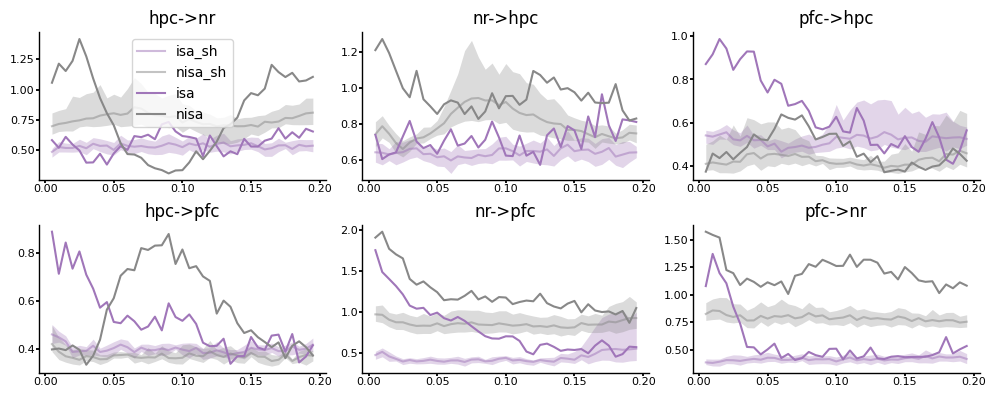

In [11]:
fig, ax = fma.plotting.makeFigure(size=(25,10),n=(2,len(regs)))
k = 0
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        if r0 != r1:
            i, j = np.unravel_index(k,ax.shape,order='F')
            f = sfit.sel(reg0=r0,reg1=r1) * 1000
            fma.plotting.semPlot(sfit.d,f.sel(isa=True,shuffle=True).T,label='isa_sh',ax=ax[i,j],color=isru.paperColors('nr','80'),alpha=0.3)
            fma.plotting.semPlot(sfit.d,f.sel(isa=False,shuffle=True).T,label='nisa_sh',ax=ax[i,j],color=isru.paperColors('shuffle','80'),alpha=0.3)
            ax[i,j].plot(sfit.d,f.sel(isa=True,shuffle=False),label='isa',color=isru.paperColors('nr'))
            ax[i,j].plot(sfit.d,f.sel(isa=False,shuffle=False),label='nisa',color=isru.paperColors('shuffle'))
            ax[i,j].set(title=f'{r0}->{r1}')
            k += 1
ax[0,0].legend();

run batch

In [ ]:
#sessions = np.arange(0,58,5)[2]
fit = fma.data.runBatch(batch_file,_regionTE,kwargs={'delay': range(1,30,2), 'shuffle': 50, 'verbose': True},parallel=False,sessions=range(0,58,5))
fit_cat = xr.concat([d for d in fit if d is not None],dim='rat',join='outer',coords='all')
t_max = fit_cat.values.argmax(axis=1)
t_max = xr.DataArray(fit_cat.d.values[t_max],coords=[fit_cat.rat,fit_cat.isa,fit_cat.reg0,fit_cat.reg1,fit_cat.shuffle])


Starting Batch, 2026-08-12 12:53:20.360794 

Batch progress: /mnt/hubel-data-131/perceval/Rat003_20231212/Rat003_20231212.xml, 1 out of 12
zeros: hpc 67.47%, nr 73.17%, pfc 84.80%
ISA: True
shuffles (out of 50): 0 cuda:0: in use=0.00 GiB, peak=0.04 GiB, pool=23.61 GiB / 23.61 GiB
1 cuda:0: in use=0.00 GiB, peak=0.04 GiB, pool=23.61 GiB / 23.61 GiB
2 cuda:0: in use=0.00 GiB, peak=0.04 GiB, pool=23.61 GiB / 23.61 GiB
3 cuda:0: in use=0.00 GiB, peak=0.04 GiB, pool=23.61 GiB / 23.61 GiB
4 cuda:0: in use=0.00 GiB, peak=0.04 GiB, pool=23.61 GiB / 23.61 GiB
5 cuda:0: in use=0.00 GiB, peak=0.04 GiB, pool=23.61 GiB / 23.61 GiB
6 cuda:0: in use=0.00 GiB, peak=0.04 GiB, pool=23.61 GiB / 23.61 GiB
7 cuda:0: in use=0.00 GiB, peak=0.04 GiB, pool=23.61 GiB / 23.61 GiB
8 cuda:0: in use=0.00 GiB, peak=0.04 GiB, pool=23.61 GiB / 23.61 GiB
9 cuda:0: in use=0.00 GiB, peak=0.04 GiB, pool=23.61 GiB / 23.61 GiB
10 cuda:0: in use=0.00 GiB, peak=0.04 GiB, pool=23.61 GiB / 23.61 GiB
11 cuda:0: in use=0.00 GiB,

E0812 15:14:19.814496 4113604 autotuner.cc:494] Could not get config for HLO: %input_reduce_fusion.6 = f32[] fusion(%input_reduce_fusion.3), kind=kInput, calls=
(param_0.1110: f32[423]) -> f32[] {
  %param_0.1110 = f32[423]{0} parameter(0)
  %constant.527.3 = f32[] constant(0), metadata={op_name="jit(scan)/while/body/closed_call/jit(_compute_pairwise_te)/vmap(jit(compute_cond_mi))/jit(entropy_bin)" stack_frame_id=79}
  ROOT %reduce.17.1 = f32[] reduce(%param_0.1110, %constant.527.3), dimensions={0}, to_apply=
  (reduce_sum.3: f32[], reduce_sum.4: f32[]) -> f32[] {
    %reduce_sum.3 = f32[] parameter(0), metadata={op_name="reduce_sum"}
    %reduce_sum.4 = f32[] parameter(1), metadata={op_name="reduce_sum"}
    ROOT %reduce_sum.5.0 = f32[] add(%reduce_sum.3, %reduce_sum.4), metadata={op_name="reduce_sum" stack_frame_id=2}
  }, metadata={op_name="jit(scan)/while/body/closed_call/jit(_compute_pairwise_te)/vmap(jit(compute_cond_mi))/jit(entropy_bin)/reduce_sum" stack_frame_id=92}
}, metadat

Error in session /mnt/hubel-data-139/karadoc/Rat004_20240227/Rat004_20240227.xml
INTERNAL: Autotuning failed for HLO: %input_reduce_fusion.6 = f32[] fusion(%input_reduce_fusion.3), kind=kInput, calls=%fused_reduce.6, metadata={op_name="jit(scan)/while/body/closed_call/jit(_compute_pairwise_te)/vmap(jit(compute_cond_mi))/jit(entropy_bin)/reduce_sum" deduplicated_name="input_reduce_fusion.5" stack_frame_id=92}. Failed to pick best config: All configs failed during profiling.
Failures (2):
EXECUTION FAILED: RESOURCE_EXHAUSTED: [0] Failed to get module function input_reduce_fusion_6: CUDA_ERROR_OUT_OF_MEMORY: out of memory
EXECUTION FAILED: RESOURCE_EXHAUSTED: [0] Failed to get module function input_reduce_fusion_6: CUDA_ERROR_OUT_OF_MEMORY: out of memory
Traceback:
/mnt/hubel-data-103/Pietro/Code/Python/RegionsPython/fmatoolbox/src/fmatoolbox/data.py, line 627, in runBatch
/tmp/ipykernel_4113604/2731461484.py, line 26, in _regionTE
/home/pietro/uvEnvs/hoi/lib/python3.12/site-packages/hoi/

E0812 15:14:21.728396 4113604 autotuner.cc:494] Could not get config for HLO: %input_reduce_fusion.6 = f32[] fusion(%input_reduce_fusion.3), kind=kInput, calls=
(param_0.1138: f32[421]) -> f32[] {
  %param_0.1138 = f32[421]{0} parameter(0)
  %constant.527.3 = f32[] constant(0), metadata={op_name="jit(scan)/while/body/closed_call/jit(_compute_pairwise_te)/vmap(jit(compute_cond_mi))/jit(entropy_bin)" stack_frame_id=79}
  ROOT %reduce.17.1 = f32[] reduce(%param_0.1138, %constant.527.3), dimensions={0}, to_apply=
  (reduce_sum.3: f32[], reduce_sum.4: f32[]) -> f32[] {
    %reduce_sum.3 = f32[] parameter(0), metadata={op_name="reduce_sum"}
    %reduce_sum.4 = f32[] parameter(1), metadata={op_name="reduce_sum"}
    ROOT %reduce_sum.5.0 = f32[] add(%reduce_sum.3, %reduce_sum.4), metadata={op_name="reduce_sum" stack_frame_id=2}
  }, metadata={op_name="jit(scan)/while/body/closed_call/jit(_compute_pairwise_te)/vmap(jit(compute_cond_mi))/jit(entropy_bin)/reduce_sum" stack_frame_id=92}
}, metadat

Error in session /mnt/hubel-data-140/karadoc/Rat004_20240308/Rat004_20240308.xml
INTERNAL: Autotuning failed for HLO: %input_reduce_fusion.6 = f32[] fusion(%input_reduce_fusion.3), kind=kInput, calls=%fused_reduce.6, metadata={op_name="jit(scan)/while/body/closed_call/jit(_compute_pairwise_te)/vmap(jit(compute_cond_mi))/jit(entropy_bin)/reduce_sum" deduplicated_name="input_reduce_fusion.5" stack_frame_id=92}. Failed to pick best config: All configs failed during profiling.
Failures (2):
EXECUTION FAILED: RESOURCE_EXHAUSTED: [0] Failed to get module function input_reduce_fusion_6: CUDA_ERROR_OUT_OF_MEMORY: out of memory
EXECUTION FAILED: RESOURCE_EXHAUSTED: [0] Failed to get module function input_reduce_fusion_6: CUDA_ERROR_OUT_OF_MEMORY: out of memory
Traceback:
/mnt/hubel-data-103/Pietro/Code/Python/RegionsPython/fmatoolbox/src/fmatoolbox/data.py, line 627, in runBatch
/tmp/ipykernel_4113604/2731461484.py, line 26, in _regionTE
/home/pietro/uvEnvs/hoi/lib/python3.12/site-packages/hoi/

...

Error in session /mnt/hubel-data-140/karadoc/Rat004_20240319/Rat004_20240319.xml
INTERNAL: Autotuning failed for HLO: %input_reduce_fusion.6 = f32[] fusion(%input_reduce_fusion.3), kind=kInput, calls=%fused_reduce.6, metadata={op_name="jit(scan)/while/body/closed_call/jit(_compute_pairwise_te)/vmap(jit(compute_cond_mi))/jit(entropy_bin)/reduce_sum" deduplicated_name="input_reduce_fusion.5" stack_frame_id=92}. Failed to pick best config: All configs failed during profiling.
Failures (2):
EXECUTION FAILED: RESOURCE_EXHAUSTED: [0] Failed to get module function input_reduce_fusion_6: CUDA_ERROR_OUT_OF_MEMORY: out of memory
EXECUTION FAILED: RESOURCE_EXHAUSTED: [0] Failed to get module function input_reduce_fusion_6: CUDA_ERROR_OUT_OF_MEMORY: out of memory
Traceback:
/mnt/hubel-data-103/Pietro/Code/Python/RegionsPython/fmatoolbox/src/fmatoolbox/data.py, line 627, in runBatch
/tmp/ipykernel_4113604/2731461484.py, line 26, in _regionTE
/home/pietro/uvEnvs/hoi/lib/python3.12/site-packages/hoi/

E0812 15:14:26.875771 4113604 autotuner.cc:494] Could not get config for HLO: %input_reduce_fusion.6 = f32[] fusion(%input_reduce_fusion.3), kind=kInput, calls=
(param_0.1110: f32[491]) -> f32[] {
  %param_0.1110 = f32[491]{0} parameter(0)
  %constant.527.3 = f32[] constant(0), metadata={op_name="jit(scan)/while/body/closed_call/jit(_compute_pairwise_te)/vmap(jit(compute_cond_mi))/jit(entropy_bin)" stack_frame_id=79}
  ROOT %reduce.17.1 = f32[] reduce(%param_0.1110, %constant.527.3), dimensions={0}, to_apply=
  (reduce_sum.3: f32[], reduce_sum.4: f32[]) -> f32[] {
    %reduce_sum.3 = f32[] parameter(0), metadata={op_name="reduce_sum"}
    %reduce_sum.4 = f32[] parameter(1), metadata={op_name="reduce_sum"}
    ROOT %reduce_sum.5.0 = f32[] add(%reduce_sum.3, %reduce_sum.4), metadata={op_name="reduce_sum" stack_frame_id=2}
  }, metadata={op_name="jit(scan)/while/body/closed_call/jit(_compute_pairwise_te)/vmap(jit(compute_cond_mi))/jit(entropy_bin)/reduce_sum" stack_frame_id=92}
}, metadat

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230816/Rat002_20230816.xml
INTERNAL: Autotuning failed for HLO: %input_reduce_fusion.6 = f32[] fusion(%input_reduce_fusion.3), kind=kInput, calls=%fused_reduce.6, metadata={op_name="jit(scan)/while/body/closed_call/jit(_compute_pairwise_te)/vmap(jit(compute_cond_mi))/jit(entropy_bin)/reduce_sum" deduplicated_name="input_reduce_fusion.5" stack_frame_id=92}. Failed to pick best config: All configs failed during profiling.
Failures (2):
EXECUTION FAILED: RESOURCE_EXHAUSTED: [0] Failed to get module function input_reduce_fusion_6: CUDA_ERROR_OUT_OF_MEMORY: out of memory
EXECUTION FAILED: RESOURCE_EXHAUSTED: [0] Failed to get module function input_reduce_fusion_6: CUDA_ERROR_OUT_OF_MEMORY: out of memory
Traceback:
/mnt/hubel-data-103/Pietro/Code/Python/RegionsPython/fmatoolbox/src/fmatoolbox/data.py, line 627, in runBatch
/tmp/ipykernel_4113604/2731461484.py, line 26, in _regionTE
/home/pietro/uvEnvs/hoi/lib/python3.12/site-packa

E0812 15:14:30.724293 4113604 autotuner.cc:494] Could not get config for HLO: %input_reduce_fusion.3 = f32[] fusion(%get-tuple-element.130), kind=kInput, calls=
(param_0.1086: f32[697]) -> f32[] {
  %param_0.1086 = f32[697]{0} parameter(0)
  %constant.527.3 = f32[] constant(0), metadata={op_name="jit(scan)/while/body/closed_call/jit(_compute_pairwise_te)/vmap(jit(compute_cond_mi))/jit(entropy_bin)" stack_frame_id=79}
  ROOT %reduce.17.1 = f32[] reduce(%param_0.1086, %constant.527.3), dimensions={0}, to_apply=
  (reduce_sum.3: f32[], reduce_sum.4: f32[]) -> f32[] {
    %reduce_sum.3 = f32[] parameter(0), metadata={op_name="reduce_sum"}
    %reduce_sum.4 = f32[] parameter(1), metadata={op_name="reduce_sum"}
    ROOT %reduce_sum.5.0 = f32[] add(%reduce_sum.3, %reduce_sum.4), metadata={op_name="reduce_sum" stack_frame_id=2}
  }, metadata={op_name="jit(scan)/while/body/closed_call/jit(_compute_pairwise_te)/vmap(jit(compute_cond_mi))/jit(entropy_bin)/reduce_sum" stack_frame_id=92}
}, metadat

Error in session /mnt/hubel-data-149/Rat011/Rat011_2025-12-11/Rat011_2025-12-11.xml
INTERNAL: Autotuning failed for HLO: %input_reduce_fusion.3 = f32[] fusion(%get-tuple-element.130), kind=kInput, calls=%fused_reduce.3, metadata={op_name="jit(scan)/while/body/closed_call/jit(_compute_pairwise_te)/vmap(jit(compute_cond_mi))/jit(entropy_bin)/reduce_sum" deduplicated_name="input_reduce_fusion.2" stack_frame_id=92}. Failed to pick best config: All configs failed during profiling.
Failures (2):
EXECUTION FAILED: RESOURCE_EXHAUSTED: [0] Failed to get module function input_reduce_fusion_3: CUDA_ERROR_OUT_OF_MEMORY: out of memory
EXECUTION FAILED: RESOURCE_EXHAUSTED: [0] Failed to get module function input_reduce_fusion_3: CUDA_ERROR_OUT_OF_MEMORY: out of memory
Traceback:
/mnt/hubel-data-103/Pietro/Code/Python/RegionsPython/fmatoolbox/src/fmatoolbox/data.py, line 627, in runBatch
/tmp/ipykernel_4113604/2731461484.py, line 26, in _regionTE
/home/pietro/uvEnvs/hoi/lib/python3.12/site-packages/h

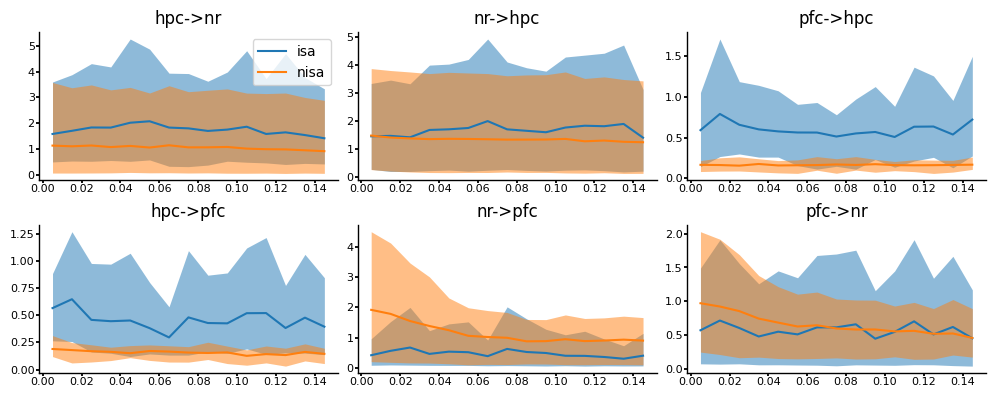

In [47]:
fig, ax = fma.plotting.makeFigure(size=(25,10),n=(2,len(regs)))
k = 0
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        if r0 != r1:
            i, j = np.unravel_index(k,ax.shape,order='F')
            f = fit_cat.sel(reg0=r0,reg1=r1) * 1000
            fma.plotting.semPlot(fit_cat.d,f.sel(isa=True,shuffle=False),label='isa',ax=ax[i,j])
            fma.plotting.semPlot(fit_cat.d,f.sel(isa=False,shuffle=False),label='nisa',ax=ax[i,j])
            ax[i,j].set(title=f'{r0}->{r1}')
            k += 1
ax[0,0].legend();

In [48]:
# find peaks with unexpected value
peak = fit_cat.max(dim='d')
p_val = xr.DataArray(fma.analysis.MCpValue(np.permute_dims(peak.sel(shuffle=True).values,(-1,0,1,2,3)), peak.sel(shuffle=False)), coords=[fit_cat.rat,fit_cat.isa,fit_cat.reg0,fit_cat.reg1])

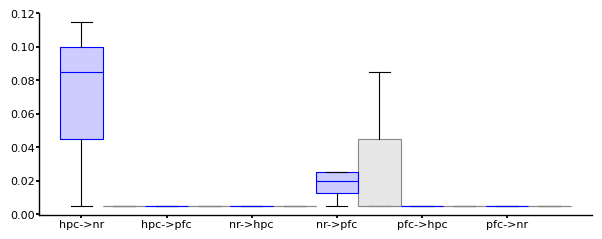

In [49]:
fig, ax = fma.plotting.makeFigure(size=(15,6))
x = np.arange(6)
data_isa = []
data_nisa = []
names = []
for i, r0 in enumerate(regs):
    for j, r1 in enumerate(regs):
        if r0 != r1:
            t = t_max.sel(isa=True,reg0=r0,reg1=r1,shuffle=False).values
            data_isa.append(t[p_val.sel(isa=True,reg0=r0,reg1=r1).values < 0.05])
            t = t_max.sel(isa=False,reg0=r0,reg1=r1,shuffle=False).values
            data_nisa.append(t[p_val.sel(isa=False,reg0=r0,reg1=r1).values < 0.05])
            names.append(f'{r0}->{r1}')
fma.plotting.boxPlot(data_nisa,x=x+0.5,ax=ax[0],color=isru.paperColors('shuffle'))
fma.plotting.boxPlot(data_isa,x=x,ax=ax[0],label=names)